In [64]:
import os
from typing_extensions import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph import StateGraph, add_messages
from openai import OpenAI
from rich.console import Console
from rich.panel import Panel
from rich.pretty import Pretty
from pydantic import BaseModel, Field
from langchain_tavily import TavilySearch
from rich import print
from langchain.agents import create_agent
from typing import Annotated, Literal
from rich.markdown import Markdown
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper


console = Console()

def show(response):
    console.print(
        Panel(
            # Pretty(response.model_dump()),
            Pretty(response),
            title="🤖 LLM Response",
            border_style="green",
            expand=False
        )
    )

def show_markdown(response):
    Console().print(Markdown(response))

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

# llm = ChatOpenAI(
#     model="stepfun/step-3.5-flash:free",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="deepseek/deepseek-v3.2",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="x-ai/grok-4.1-fast",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-4o-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

# llm = ChatOpenAI(
#     model="openai/gpt-5-nano",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="anthropic/claude-haiku-4.5",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash-lite",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

In [50]:
class llm_schema(BaseModel):
    topic: str = Field(..., description="Topic of the post to generate")
    category: Literal['insta', 'linkedin', 'twitter'] = Field(..., description="Category of the post to generate")

In [51]:
llm_with_schema = llm.with_structured_output(llm_schema)
response = llm_with_schema.invoke("I want to generate a post for twitter about AI")
print(response)

llm_schema(
    topic="AI is reshaping our world faster than ever— from creative art generators to intelligent assistants. 
Embrace the possibilities, stay curious, and let's shape a responsible future together! #AI #TechTrends",
    category='twitter'
)

In [52]:
class graph_schema(BaseModel):
    input: str = Field(..., description="User Input")
    topic: str = Field(..., description="Topic for the post")
    category: str = Field(..., description="Category of the platform for which the post is being generated")
    post: str = Field(..., description="Generated post")

In [53]:
def insta_post(state: graph_schema) -> graph_schema:
    topic = state.topic
    post = llm.invoke(f"Generate a post for instagram on this topic: {topic}. Keep the tone casual and engaging.").content
    state.post = post
    return state

In [54]:
def twitter_post(state: graph_schema) -> graph_schema:
    topic = state.topic
    post = llm.invoke(f"Generate a post for twitter on this topic: {topic}. Keep the tone quick").content
    state.post = post
    return state

In [55]:
def linkedin_post(state: graph_schema) -> graph_schema:
    topic = state.topic
    post = llm.invoke(f"Generate a post for linkedin on this topic: {topic}. Keep the tone professional and informative").content
    state.post = post
    return state

In [56]:
def decider(state: graph_schema) -> graph_schema:
    user_input = state.input
    response = llm_with_schema.invoke(user_input)
    category = response.category
    topic = response.topic
    state.category = category
    state.topic = topic
    return state

In [57]:
def condition(state: graph_schema) -> str:
    category = state.category
    if category == 'insta':
        return 'insta'
    elif category == 'twitter':
        return 'twitter'
    elif category == 'linkedin':
        return 'linkedin'
    else:
        raise ValueError("Invalid Category")

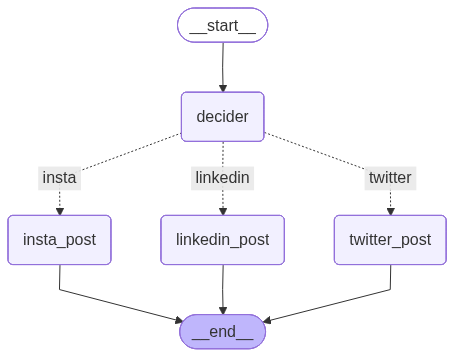

In [58]:
graph = StateGraph(graph_schema)

graph.add_node('decider', decider)
graph.add_node('insta_post', insta_post)
graph.add_node('twitter_post', twitter_post)
graph.add_node('linkedin_post', linkedin_post)

graph.add_edge(START, 'decider')
graph.add_conditional_edges('decider', condition, {
    'insta': "insta_post",
    'twitter': "twitter_post",
    'linkedin': "linkedin_post",
})
graph.add_edge("insta_post", END)
graph.add_edge("twitter_post", END)
graph.add_edge("linkedin_post", END)

post_graph = graph.compile()

from IPython.display import Image, display
Image(post_graph.get_graph().draw_mermaid_png())

In [59]:
response = post_graph.invoke(graph_schema(
    input = "Create an insta post on AI.",
    topic  = "",
    category = "",
    post = "",
))

In [62]:
print(response)

{
    'input': 'Create an insta post on AI.',
    'topic': 'AI',
    'category': 'insta',
    'post': '**Caption**  \n🤖✨ Hey Insta‑fam! Ever wonder what AI *actually* does behind the scenes? From 
perfecting your selfie filter to recommending that binge‑worthy series, AI is the silent sidekick making our 
digital lives smoother, smarter, and a little bit cooler. 🌟  \n\n🔹 **Fun fact:** The word “algorithm” is just a 
fancy way of saying “a recipe for a computer.” 🍰  \n🔹 **Did you know?** Your phone’s voice assistant learns 
*your* voice over time—so it gets better at understanding you with every “Hey Siri/Google!” 🎤  \n🔹 **Pro tip:** 
Want to boost your creativity? Try using AI‑powered tools like DALL·E or ChatGPT for quick brainstorming. Your 
brain + AI = unstoppable ideas! 💡  \n\nWhat’s the coolest AI trick you’ve discovered? Drop it below ⬇️ and let’s 
geek out together!  \n\n✌️ #AI #ArtificialIntelligence #TechTalk #FutureIsNow #DigitalLife #Techie #Innovation 
#AIar #Storytelling #CreativeTech #InstaTech #LearnEveryday #StayCurious  '
}

In [65]:
show(response)

╭──────────────────────────────────────────────── 🤖 LLM Response ────────────────────────────────────────────────╮
│ {                                                                                                               │
│     'input': 'Create an insta post on AI.',                                                                     │
│     'topic': 'AI',                                                                                              │
│     'category': 'insta',                                                                                        │
│     'post': '**Caption**  \n🤖✨ Hey Insta‑fam! Ever wonder what AI *actually* does behind the scenes? From     │
│ perfecting your selfie filter to recommending that binge‑worthy series, AI is the silent sidekick making our    │
│ digital lives smoother, smarter, and a little bit cooler. 🌟  \n\n🔹 **Fun fact:** The word “algorithm” is just │
│ a fancy way of saying “a recipe for a computer.” 🍰  \n🔹 **Did you know?** Your phone’s voice assistant learns │
│ *your* voice over time—so it gets better at understanding you with every “Hey Siri/Google!” 🎤  \n🔹 **Pro      │
│ tip:** Want to boost your creativity? Try using AI‑powered tools like DALL·E or ChatGPT for quick               │
│ brainstorming. Your brain + AI = unstoppable ideas! 💡  \n\nWhat’s the coolest AI trick you’ve discovered? Drop │
│ it below ⬇️ and let’s geek out together!  \n\n✌️ #AI #ArtificialIntelligence #TechTalk #FutureIsNow             │
│ #DigitalLife #Techie #Innovation #AIar #Storytelling #CreativeTech #InstaTech #LearnEveryday #StayCurious  '    │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [63]:
show_markdown(response['post'])

Caption                                                                                                            
🤖✨ Hey Insta‑fam! Ever wonder what AI actually does behind the scenes? From perfecting your selfie filter to     
recommending that binge‑worthy series, AI is the silent sidekick making our digital lives smoother, smarter, and a 
little bit cooler. 🌟                                                                                              

🔹 Fun fact: The word “algorithm” is just a fancy way of saying “a recipe for a computer.” 🍰                      
🔹 Did you know? Your phone’s voice assistant learns your voice over time—so it gets better at understanding you   
with every “Hey Siri/Google!” 🎤                                                                                   
🔹 Pro tip: Want to boost your creativity? Try using AI‑powered tools like DALL·E or ChatGPT for quick             
brainstorming. Your brain + AI = unstoppable ideas! 💡                                                             

What’s the coolest AI trick you’ve discovered? Drop it below ⬇️ and let’s geek out together!                       

✌️ #AI #ArtificialIntelligence #TechTalk #FutureIsNow #DigitalLife #Techie #Innovation #AIar #Storytelling         
#CreativeTech #InstaTech #LearnEveryday #StayCurious

In [66]:
response = post_graph.invoke(graph_schema(
    input = "Create a twitter post on AI.",
    topic  = "",
    category = "",
    post = "",
))

show(response)

╭──────────────────────────────────────────────── 🤖 LLM Response ────────────────────────────────────────────────╮
│ {                                                                                                               │
│     'input': 'Create a twitter post on AI.',                                                                    │
│     'topic': 'AI',                                                                                              │
│     'category': 'twitter',                                                                                      │
│     'post': '🚀 AI is sprinting ahead—think smarter assistants, deeper insights, and creative partners that     │
│ actually get you. Ready to ride the wave or get left in the static? #AI #FutureNow #TechBuzz 🤖💡'              │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯